In [1]:
!pip install pip install umap-learn
!pip install pytorch-lightning
import tarfile
from PIL import Image
from glob import glob
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
from tqdm.notebook import tqdm
import pandas as pd
import umap
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping

ERROR: Could not find a version that satisfies the requirement install (from versions: none)
ERROR: No matching distribution found for install
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.0/823.0 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 8

In [2]:
import matplotlib
font = {'weight' : 'regular',
        'size'   : 22}

matplotlib.rc('font', **font)

In [3]:
!curl -O https://gist.githubusercontent.com/jszym/479db2af32411b64249bfb1bff43a95e/raw/1bef32b78e6ddd414beebe6e57cf3b0a0fac44ea/dictlogger.py
from dictlogger import DictLogger

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1610  100  1610    0     0   5779      0 --:--:-- --:--:-- --:--:--  5791


# ECSE552 - W25 - Assignment 2 - Part 2 (Total 20 points)

## Conditional Variational Autoencoders

### Note

***Clearly comment each of your steps. Failure to do so would result in loss of points.***
**Additionally explain each line in your code**

### Introduction

Conditional Variational Autoencoders (CVAEs) are an extension of Variational Autoencoders (VAEs).

As we explored in tutorial eight, VAEs are comprised of two main parts: an encoder and a decoder.

The encoder approximates the function $Q(z|X)$ and the decoder approximates the function $P(X|z)$.

As a reminder, here $X$ is the input data and $z$ is a latent vector.

For more details, you might consider this [Tutorial on Variational Autoencoders](https://arxiv.org/abs/1606.05908) by Carl Doersch.

The above formulation, however, does not allow us to generate specific images. For example, given a model trained on the MNIST digits, it's difficult to fully explore the latent space for a given digit.

We can solve this by conditioning $P$ by not only the latent vector $z$, but some value $c$ that can encode information, (_e.g._: which MNIST digit we're generating).

This would mean our decoder would got from $P(X|z)$ in the VAE case to $P(X|z,c)$ in the CVAE case.

### Practical Implementation

Practically, this means that a "conditional" vector $c$ is passed to the decoder. This is commonly a class label for the sample that is one-hot encoded, but it can be anything you wish to marginalise the model by.

Below is a very high-level illustration of both a Variational Autoencoder (VAE) and a Conditional Variational Autoencoder (CVAE). Components of the CVAE that are not present in the VAE are demarked with a yellow star.

The CVAE is identical to the VAE, but for the concatenation of the vector $c$ to the vector $z$ before being inputted into the decoder. The loss function does not change in any way.

In this diagram the dimensions are noted for all the inputs and outputs of the Encoder and Decoder.

The dimension variables are as follows:

* $m$ is the batch size
* $w$ is the width of the image inputted into our encoder
* $h$ is the height of the image inputted into our encoder
* $n$ is the number of latent variables
* $q$ is the width of the conditional vector. If $c$ represents the class of the image, then $q$ is often equal to the number of classes.

<img src="https://ecse552.b-cdn.net/W24/H3/vae_cvae.webp" alt="VAE vs CVAE" width="50%"/>

Let's look closer at the concatenation of $z$ and $c$, as well as the representation of $c$. Consider the case of a CVAE where the samples are MNIST digits and $c$ is the one-hot encoded class of the digit. In this example, the number of latent variables ($n$ in the diagram above) is 3. Below is an illustration of what the concatenation might look like.

![Concatenating z with c](https://ecse552.b-cdn.net/W24/H3/conditional_z.webp)

The vectors that are the result of concatenating $z$ and $c$ (let's call it $z_c$) then become the input to the decoder.

### Q1.1 - Implementing an MNIST CVAE (10 points)

Your task is to extend the MNIST VAE from Tutorial 8 to a CVAE.

Specifically, you must:

1. Correctly define a conditional vector $c$ in the training loop.
2. Correctly concatenate it to $z$ to form $z_c$.
3. Input $z_c$ to the Decoder.
4. Make any further nescessary modifications to the code.

You are provided with the complete code for the MNIST VAE presented in Tutorial 8, including data loaders, encoders, decoders, and training/validation loops.

The number of latent variables for this excercise ($n$) is set to 10.

**Hint**: While you are permitted to make changes to the Encoder and Decoder class, it is not nescessary to correctly answer this question.

**Another Hint**: You can correctly answer this question by modifying/adding no more than six lines.

In [4]:
class MNISTDataset(Dataset):

    def __init__(self, csv_path):

        self.df = pd.read_csv(csv_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        return torch.tensor(self.df.iloc[idx][1:])/255, self.df.iloc[idx][0]

In [5]:
batch_size = 100

dataset = MNISTDataset('./sample_data/mnist_train_small.csv')

num_test = len(dataset) // 10
num_train = len(dataset) - num_test
dataset_train, dataset_test = random_split(dataset, [num_train, num_test])

dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
dataloader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=True)

In [6]:
class Encoder(nn.Module):
    def __init__(self, in_dim, latent_dim):
        super(Encoder, self).__init__()

        self.layer0 = nn.Linear(in_dim, 1024)
        self.layer1 = nn.Linear(512, 768)
        self.layer2 = nn.Linear(768, 1024)
        self.layer3 = nn.Linear(512, 256)
        self.layer4 = nn.Linear(128, latent_dim)

        self.pool = nn.MaxPool1d(2)

        self.dropout = nn.Dropout(0.3)

        self.activation = nn.LeakyReLU(0.01)

    def forward(self, x):

        x = self.layer0(x)
        x = self.activation(x)

        x = self.dropout(x)

        x = x.reshape(x.shape[0], 1, x.shape[1])
        x = self.pool(x)
        x = x.reshape(x.shape[0], x.shape[2])

        x = self.layer1(x)
        x = self.activation(x)

        x = self.dropout(x)

        x = self.layer2(x)
        x = self.activation(x)

        x = self.dropout(x)

        x = x.reshape(x.shape[0], 1, x.shape[1])
        x = self.pool(x)
        x = x.reshape(x.shape[0], x.shape[2])

        x = self.layer3(x)
        x = self.activation(x)

        x = self.dropout(x)

        x = x.reshape(x.shape[0], 1, x.shape[1])
        x = self.pool(x)
        x = x.reshape(x.shape[0], x.shape[2])

        x = self.layer4(x)
        x = self.activation(x)

        return x

In [7]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, out_dim):
        super(Decoder, self).__init__()

        self.layer4 = nn.Linear(784, out_dim)
        self.layer3 = nn.Linear(768, 784)
        self.layer2 = nn.Linear(1024, 768)
        self.layer1 = nn.Linear(256, 1024)
        self.layer0 = nn.Linear(latent_dim, 256)

        self.dropout = nn.Dropout(0.3)

        self.activation = nn.LeakyReLU(0.01)

    def forward(self, x):

        x = self.layer0(x)
        x = self.activation(x)

        x = self.dropout(x)

        x = self.layer1(x)
        x = self.activation(x)

        x = self.dropout(x)

        x = self.layer2(x)
        x = self.activation(x)

        x = self.dropout(x)

        x = self.layer3(x)
        x = self.activation(x)

        x = self.dropout(x)

        x = self.layer4(x)
        x = torch.sigmoid(x)

        return x

In [8]:
import torch.nn.functional as F  # To be able to make neural network operations

class MNIST_CVAE(pl.LightningModule):   # CVAE Class
    def __init__(self, in_dim, out_dim, latent_dim, num_classes): # Add number of classes (10 for MNIST)
        super(MNIST_CVAE, self).__init__()

        self.latent_dim = latent_dim
        self.num_classes = num_classes    # Initializing number of classes with input

        self.encoder = Encoder(in_dim + num_classes, latent_dim*2)  # Add 10 inputs to the encoder for the one hot encoded vector with 10 classes
        self.decoder = Decoder(latent_dim + num_classes, out_dim)   # Add 10 inputs to the decoder since the decoder will also have a bigger dimension
        self.recon_criterion = nn.BCELoss(reduction='sum')

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5*log_var)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mu)

    def loss(self, mu, logvar, pred, target):

        kld_loss = torch.sum(-0.5 * torch.sum(1 + logvar - mu ** 2 - logvar.exp(), dim = 1), dim = 0)
        recons_loss = self.recon_criterion(pred, target)

        loss = recons_loss + kld_loss

        return kld_loss, recons_loss, loss

    def forward(self, x, y):

        x = x.view(x.size(0), -1)           # To ensure x can be concatenated with
        c = F.one_hot(y, num_classes=10).float()    # Create conditional vector that will be concatenated

        x_cond = torch.cat([x, c], dim=1)  # Concatenate input x with condition vector c

        parameters= self.encoder(x_cond)    # Changed x to x_cond

        mu = parameters[:, :self.latent_dim]
        logvar = parameters[:, self.latent_dim:]

        z = self.reparameterize(mu, logvar)

        zc = torch.cat([z, c], dim=1)       # Create zc, our conditional latent space

        x_hat = self.decoder(zc) # Input zc instead of z

        return mu, logvar, x_hat

    def training_step(self, batch, batch_idx):

        x, y = batch

        mu, logvar, x_hat = self.forward(x, y)
        kld_loss, recons_loss, loss = self.loss(mu, logvar, x_hat, x)

        self.log('training_loss', loss, on_step=False, on_epoch=True)
        self.log('training_kld_loss', kld_loss, on_step=False, on_epoch=True)
        self.log('training_recons_loss', recons_loss, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):

        x, y = batch

        mu, logvar, x_hat = self.forward(x, y)

        kld_loss, recons_loss, loss = self.loss(mu, logvar, x_hat, x)

        self.log('val_loss', loss, on_step=False, on_epoch=True)
        self.log('val_kld_loss', kld_loss, on_step=False, on_epoch=True)
        self.log('val_recons_loss', recons_loss, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(dataloader_train), epochs=20)
        return [optimizer], [scheduler]

In [9]:
model = MNIST_CVAE(784, 784, 10, 10)    # Add number of classes (10 for MNIST)

In [10]:
logger = DictLogger()
early_stopping = EarlyStopping('val_loss', verbose=True, min_delta=0.0001,
                               patience=3)
trainer = pl.Trainer(accelerator = 'gpu', logger=logger, callbacks=[early_stopping],
                     max_epochs=40)


trainer.fit(model, dataloader_train, dataloader_test)

INFO:pytorch_lightning.utilities.rank_zero:You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type    | Params | Mode 
----------------------------------------------------
0 | encoder         | Encoder | 2.1 M  | train
1 | decoder         | Decoder | 2.3 M  | train
2 | recon_criterion | BCELoss | 0      | train
----------------------------------------------------
4.4 M     Trainable params
0         Non-trainable params
4.4 M     Total params
17.614    Total estimated model params size (MB)
18        Modules in tra

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:476: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
<ipython-input-4-a9dc1761cd36>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return torch.tensor(self.df.iloc[idx][1:])/255, self.df.iloc[idx][0]


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 81.034 >= min_delta = 0.0001. New best score: 13644.416


Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 3 records. Best score: 13644.416. Signaling Trainer to stop.


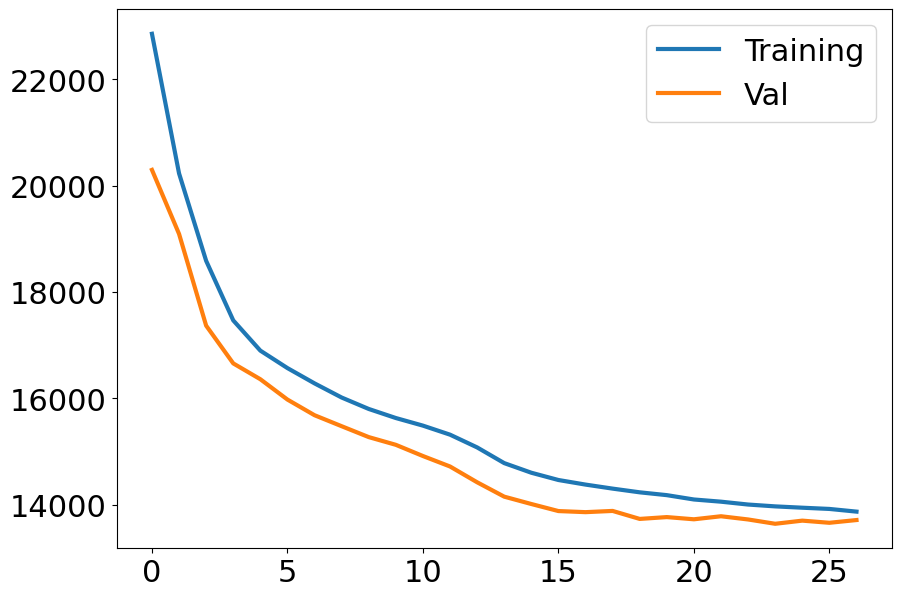

In [11]:
plt.figure(figsize=(10, 7))
plt.plot(logger.metrics['training_loss'], label='Training', lw=3)
plt.plot(logger.metrics['val_loss'], label='Val', lw=3)
plt.legend()
plt.show()

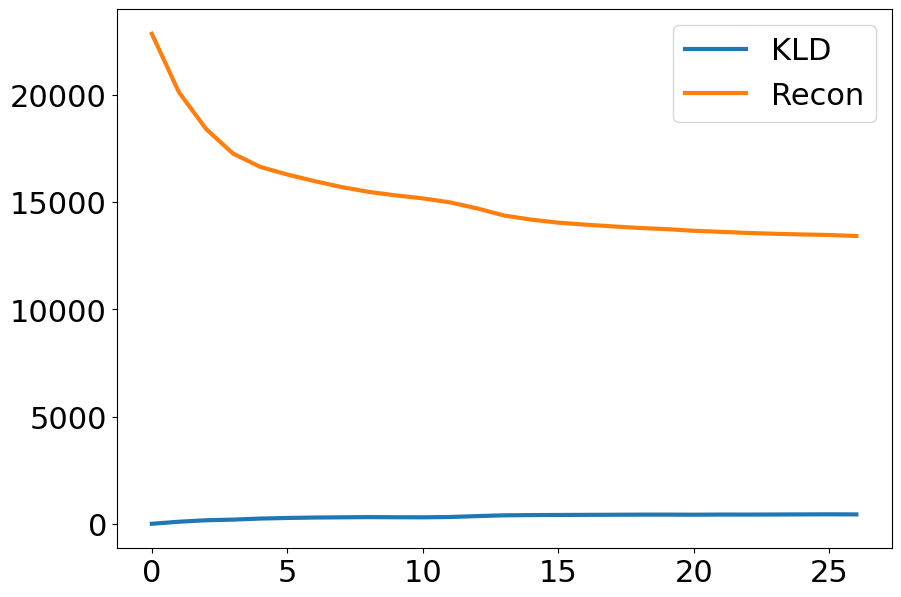

In [12]:
plt.figure(figsize=(10, 7))
plt.plot(logger.metrics['training_kld_loss'], label='KLD', lw=3)
plt.plot(logger.metrics['training_recons_loss'], label='Recon', lw=3)
plt.legend()
plt.show()


### Q1.2 Demonstrate Reconstruction (5 points)

In the same way as was demonstrated in Tutorial 8, the ability of your model to reconstruct the first two digits from the first batch provided by `dataloader_test`.

Specifically, pass the first two values of `x` and `y` from `dataloader_test` to `model` and reconstruct these images. Plot them as illustrated below:

<img src=https://ecse552.b-cdn.net/W24/H3/q1.2.webp alt="Reconstructed MNIST digits" width="35%"/>

**Note**: The batches are randomised so you won't nescessarily get the same samples shown above.

<ipython-input-4-a9dc1761cd36>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return torch.tensor(self.df.iloc[idx][1:])/255, self.df.iloc[idx][0]


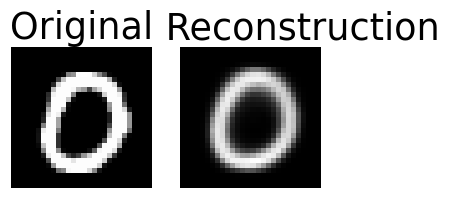

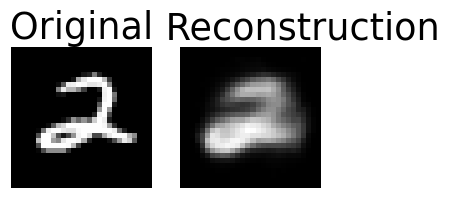

In [17]:
import matplotlib.pyplot as plt
import torch

# Get a batch from the test dataloader
x, y = next(iter(dataloader_test))

# Select first two images and labels
x = x[:2]
y = y[:2]

model.eval()

# Disable gradient tracking since no training
with torch.no_grad():
    mu, logvar, x_hat = model(x, y)

# Plot original and reconstructed images
for i in range(2):
    plt.figure(figsize=(4, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(x[i].view(28, 28).cpu(), cmap='gray')
    plt.title(f"Original")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(x_hat[i].view(28, 28).cpu(), cmap='gray')
    plt.title("         Reconstruction")
    plt.axis('off')

    plt.show()


### Q1.3 Demonstrate Conditional Reconstruction (5 points)

Similar to Q1.2, reconstruct digits, but instead of using the correct $c$ vector, change the class label to a different one.

For example, the value of `y` for the two samples below are 3 and 6, but when reconstructing, the $c$ vector `[0,0,1,0,0,0,0,0,0,0]` was supplied.

<img src="https://ecse552.b-cdn.net/W24/H3/q1.3.png" alt="Conditioned Reconstruction" width="35%"/>

<ipython-input-4-a9dc1761cd36>:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return torch.tensor(self.df.iloc[idx][1:])/255, self.df.iloc[idx][0]


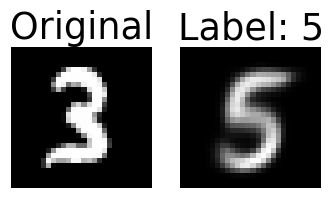

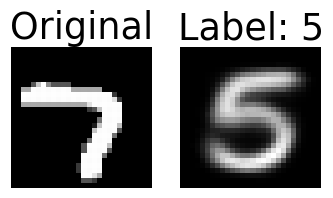

In [23]:
import matplotlib.pyplot as plt
import torch

# Get the first batch
x, y = next(iter(dataloader_test))
x = x[:2]
y_true = y[:2]

# Change the label (e.g., pretend both are class 2)
y_fake = torch.tensor([5, 5])

model.eval()
with torch.no_grad():
    mu, logvar, x_hat = model(x, y_fake)

# Plot original and reconstruction
for i in range(2):
    plt.figure(figsize=(4, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(x[i].view(28, 28).cpu(), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(x_hat[i].view(28, 28).cpu(), cmap='gray')
    plt.title("Label: 5")
    plt.axis('off')

    plt.show()
